# Setup

``` A large dataset (when compared to other studies in this domain) is considered, with white and red vinho verde samples (from Portugal). Three regression techniques were applied, under a computationally efficient procedure that performs simultaneous variable and model selection. The support vector machine achieved promising results, outperforming the multiple regression and neural network methods. Such model is useful to support the oenologist wine tasting evaluations and improve wine production. Furthermore, similar techniques can help in target marketing by modeling consumer tastes from niche markets.```


{{< include _wineQualityInfo.txt >}}

In [2]:
#| label: setup
import numpy as np
import pandas as pd
#import polars as pl
import scipy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
#import ibis
import plotly
import sys
import os
from pathlib import Path
import plotly.io as pio
pio.renderers.default = "iframe_connected+plotly_mimetype"
# add to path
data_path = Path("../datasets/red-wine-dataset/wineQualityReds.csv")
#helper_path =  Path("../helpers/")
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 7)
pd.set_option('display.precision', 8)

In [3]:
df = pd.read_csv(data_path)
df.rename(columns = {df.columns[0]: 'sample_no'}, inplace = True)
# df.set_index(['sample_no'])
df

,sample_no,fixed.acidity,volatile.acidity,...,sulphates,alcohol,quality
0,1,7.4,0.700,...,0.56,9.4,5
1,2,7.8,0.880,...,0.68,9.8,5
2,3,7.8,0.760,...,0.65,9.8,5
3,4,11.2,0.280,...,0.58,9.8,6
4,5,7.4,0.700,...,0.56,9.4,5
...,...,...,...,...,...,...,...
1594,1595,6.2,0.600,...,0.58,10.5,5
1595,1596,5.9,0.550,...,0.76,11.2,6
1596,1597,6.3,0.510,...,0.75,11.0,6
1597,1598,5.9,0.645,...,0.71,10.2,5


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sample_no             1599 non-null   int64  
 1   fixed.acidity         1599 non-null   float64
 2   volatile.acidity      1599 non-null   float64
 3   citric.acid           1599 non-null   float64
 4   residual.sugar        1599 non-null   float64
 5   chlorides             1599 non-null   float64
 6   free.sulfur.dioxide   1599 non-null   float64
 7   total.sulfur.dioxide  1599 non-null   float64
 8   density               1599 non-null   float64
 9   pH                    1599 non-null   float64
 10  sulphates             1599 non-null   float64
 11  alcohol               1599 non-null   float64
 12  quality               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB
None


The `DataFrame` has been intialised, and the index set correctly. Now, integer indexing refers to the sample number. 

#### A few things of note:
 > The inputs include objective tests (e.g. PH values) and the output is based on sensory data(median of at least 3 evaluations made by wine experts). Each expert graded the wine quality between 0 (very bad) and 10 (very excellent). Several data mining methods were applied to modelthese datasets under a regression approach. The support vector machine model achieved the best results. Several metrics were computed: MAD, confusion matrix for a fixed error tolerance (T), etc. Also, we plot the relative importances of the input variables (as measured by a sensitivity analysis procedure).
 
- Inputs: 
    1. PH Values
    2. fixed acidity (tartaric acid - ${g}/{dm^3}$)
    3. volatile acidity (acetic acid - $g / dm^3$)
    4. citric acid ($g / dm^3$)
    5. residual sugar ($g / dm^3$)
    6. chlorides (sodium chloride - $g / dm^3$)
    7. free sulfur dioxide ($mg / dm^3$)
    8. total sulfur dioxide ($mg / dm^3$)
    9. density ($g / cm^3$)
    10. pH
    11. sulphates (potassium sulphate - $g / dm3$)
    12. alcohol (% by volume)

- Output variable (based on sensory data): 

    13. quality (score between 0 and 10)

### Lets do some preliminary correllation testing. 

In [5]:
# force any strings to floats if they are there
df = df.apply(pd.to_numeric, errors='coerce')


In [6]:
#Lets see the shape and info:
print(df.shape)
print(df.info())


(1599, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sample_no             1599 non-null   int64  
 1   fixed.acidity         1599 non-null   float64
 2   volatile.acidity      1599 non-null   float64
 3   citric.acid           1599 non-null   float64
 4   residual.sugar        1599 non-null   float64
 5   chlorides             1599 non-null   float64
 6   free.sulfur.dioxide   1599 non-null   float64
 7   total.sulfur.dioxide  1599 non-null   float64
 8   density               1599 non-null   float64
 9   pH                    1599 non-null   float64
 10  sulphates             1599 non-null   float64
 11  alcohol               1599 non-null   float64
 12  quality               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB
None


In [7]:

print(df.describe())


           sample_no  fixed.acidity  volatile.acidity  ...      sulphates  \
count  1599.00000000  1599.00000000     1599.00000000  ...  1599.00000000   
mean    800.00000000     8.31963727        0.52782051  ...     0.65814884   
std     461.73585522     1.74109632        0.17905970  ...     0.16950698   
min       1.00000000     4.60000000        0.12000000  ...     0.33000000   
25%     400.50000000     7.10000000        0.39000000  ...     0.55000000   
50%     800.00000000     7.90000000        0.52000000  ...     0.62000000   
75%    1199.50000000     9.20000000        0.64000000  ...     0.73000000   
max    1599.00000000    15.90000000        1.58000000  ...     2.00000000   

             alcohol        quality  
count  1599.00000000  1599.00000000  
mean     10.42298311     5.63602251  
std       1.06566758     0.80756944  
min       8.40000000     3.00000000  
25%       9.50000000     5.00000000  
50%      10.20000000     6.00000000  
75%      11.10000000     6.00000000  
ma

In [8]:

# How many null values in the entire df? (remember we have already coerced it to numeric)
print(df.isnull().sum().sum())

0


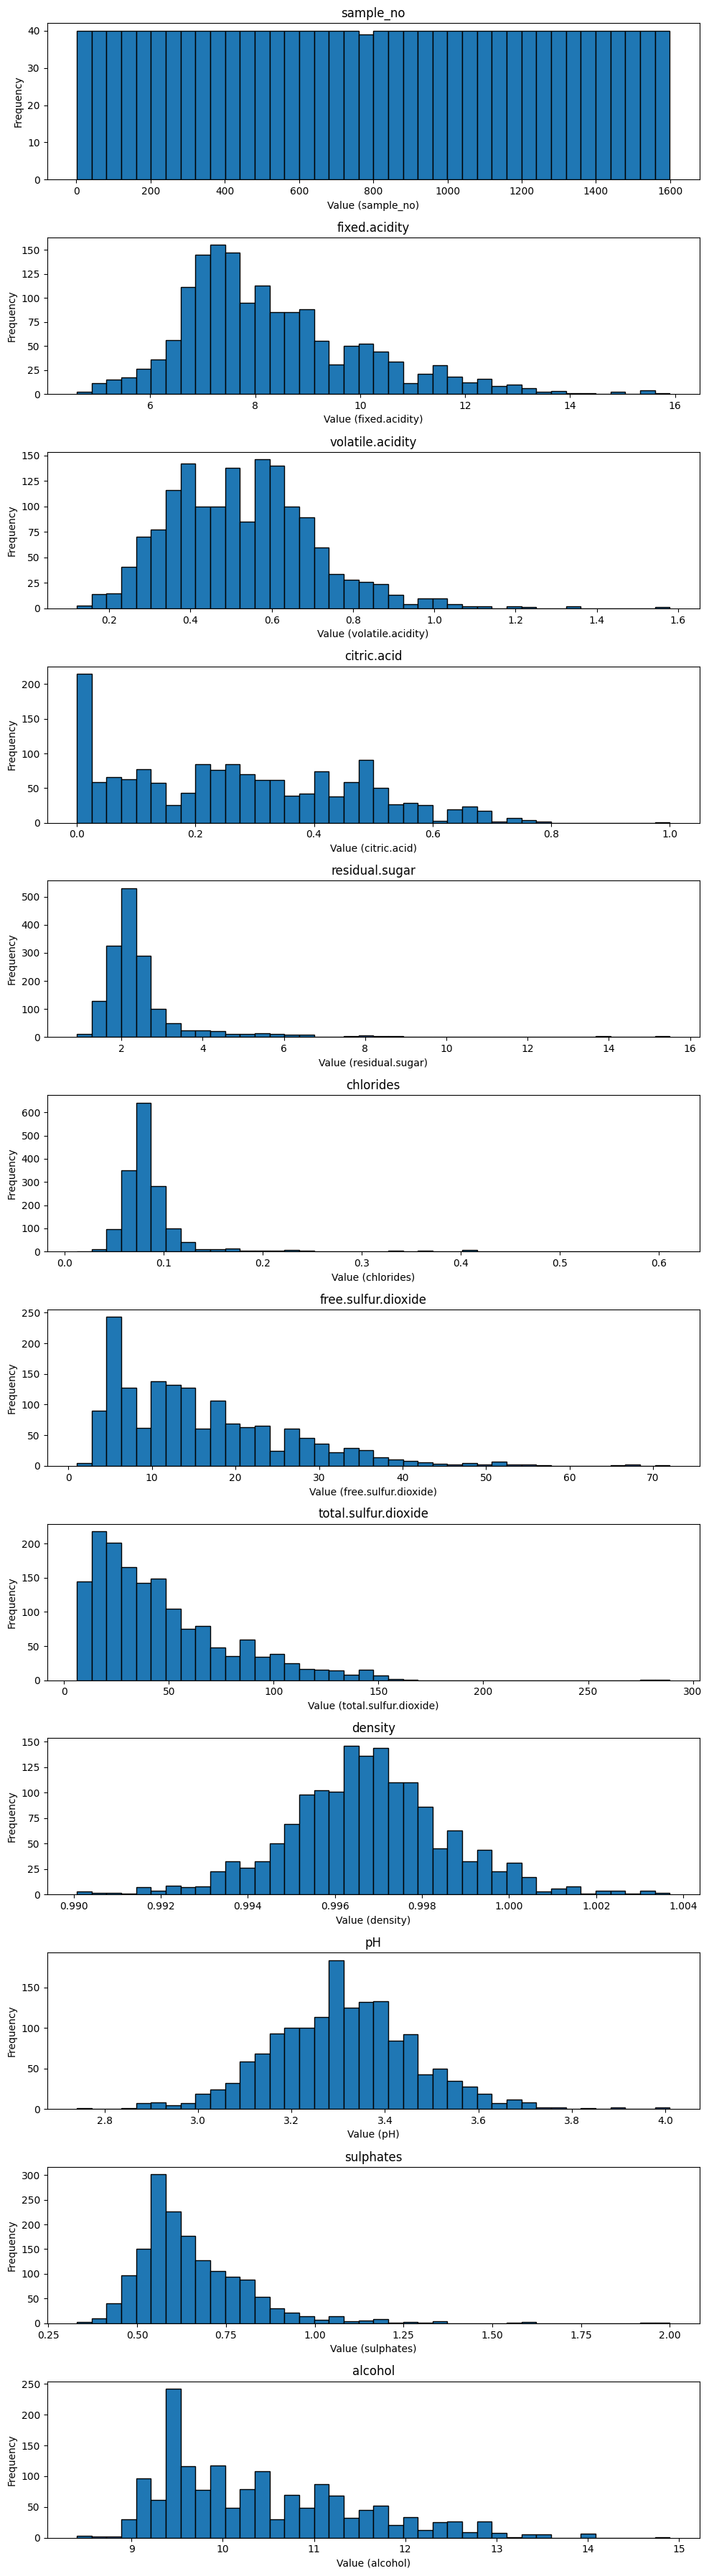

In [9]:
features = [c for c in df.columns if c != 'quality']

fig, axes = plt.subplots(len(features), 1, figsize=(10, len(features) * 3))

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=40, edgecolor='black')
    axes[i].set_title(feat)
    axes[i].set_xlabel(f'Value ({feat})')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
df.drop('sample_no', inplace=True, axis=1) #we dont need this index. 

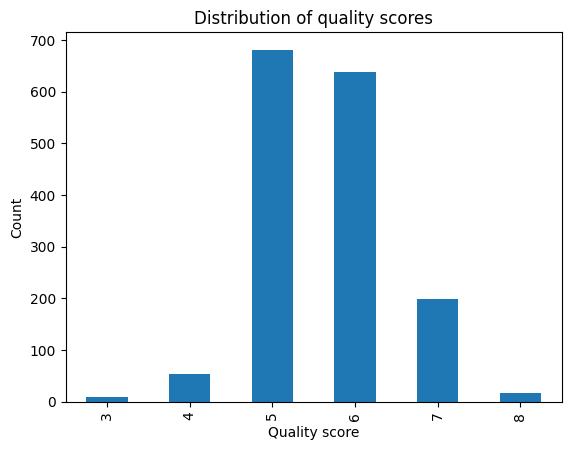

quality
3    0.00625391
4    0.03314572
5    0.42589118
6    0.39899937
7    0.12445278
8    0.01125704
Name: proportion, dtype: float64


In [11]:
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Quality score')
plt.ylabel('Count')
plt.title('Distribution of quality scores')
plt.show()

print(df['quality'].value_counts(normalize=True).sort_index())

In [ ]:
fig = plotly.plot(df, kind='scatter')
fig

We note that everything is concentrated in a very small area -- lets expand this by converting to a logarithmic scale for better visualization

In [ ]:
fig.update_yaxes(type='log')

In [ ]:
sns.scatterplot(df)

## What do we see?
The first thing we notice is that this data is not normalised. This is further pointed out at the source. Lets quickly verify. 

In [ ]:
bounds = pd.DataFrame({'max': df.max(), 'min': df.min()})
print(bounds)

Now: We need to be VERY careful. Not all of these values scale linearly. Notably, pH is on a loagrithmic scale. We thus need to convert it to a concentration to match the rest of the data. 

1. sample_no: No scaling, this is the sample identifier
2. fixed.acidity: concentration of tartaric acid in $g\cdot d^{-1}m^{-3}$
3. volatile acidity: concentration of acetic acid in $g\cdot d^{-1}m^{-3}$
4. concentration of citric acid in $g\cdot d^{-1}m^{-3}$
5. residual sugar ($g / dm^3$)
6. chlorides (sodium chloride - $g / dm^3$)
7. free sulfur dioxide ($mg / dm^3$) --  ***Note scaling is $mg\cdot (dm)^{-3}$***
8. total sulfur dioxide ($mg / dm^3$) -- ***Note scaling is $mg\cdot (dm)^{-3}$***
9. density: Measurement of the mass per unit volume ($g / cm^3$) -- ***Note scaling is $g\cdot (cm)^{-3}$***
10. pH: ***Logarithmic*** -- Must be converted to concentration of hydronium ions
11. sulphates (potassium sulphate - $g / dm3$)
12. alcohol (% by volume)

In [ ]:
sns.heatmap(df.corr('kendall'))

In [ ]:
sns.heatmap(df.corr('pearson'))

In [ ]:
sns.heatmap(df.corr('spearman'))

Based on these three heatmaps, each with their different strengths and weaknesses, we can see that there are some areas of extremely clear corellation, but the relationship becomes less clear when evaluating them against the output quality score. 

**Pearson Correlation $r$**: Measures the linear association between two continuous variables. It tells you how closely your data fits a straight line.
***Requirements:*** Normally distributed data, linear relationship, continuous variables.
***Weakness:*** Highly sensitive to outliers

**Spearman Rank Correlation ($\rho$)**: Measures the monotonic relationship between two variables—how well they change together, even if not at a constant rate. It ranks the data first.

***Requirements:*** Ordinal or continuous data; non-parametric (no normality assumed).

***Strength:*** Useful for non-linear, monotonic data and robust against outliers.

**Kendall Rank Correlation ($\tau$)**: Measures the strength of dependence between two variables using the order of rankings (concordant/discordant pairs).

***Requirements:*** Ordinal or continuous data; non-parametric.
***Strength:*** Much more robust and efficient with small sample sizes and tied ranks compared to Spearman.


Use Pearson if your data is continuous and has a clear linear relationship.Use Spearman if your data is ranked, ordinal, or non-linear but monotonic.Use Kendall if you have a small dataset, many ties in rankings, or need to measure ordinal association